In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import scanpy as sc
import pandas as pd
import numpy as np
import scipy.stats as st

pd.set_option('future.no_silent_downcasting', True)

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata)

In [3]:
adata.obs['clone'] = pd.read_csv('../../6_figure_MPN_AML_phylogeny/output/clone_assignments.csv', index_col=0)['clone']

In [4]:
def get_genotype_stats(adata, clone, variant, isolate_cluster=False, cluster = ''):
    adata.obs['max_prob'] = adata.obsm['genotypes'][[f'{variant}_wt', f'{variant}_mutated', f'{variant}_heterozygous']].max(axis=1)

    genotype_frac = {'wt' : {},
                    'mutated' : {},
                    'heterozygous' : {}}
    UMI_counts = {}

    for threshold in np.arange(0.6, 1.01, 0.01):
        condition = (adata.obs['clone'] == clone) & (adata.obs['max_prob'] > threshold)
        if isolate_cluster:
            condition = condition & (adata.obs['pheno_leiden'] == cluster)
        if len(adata[condition].obs) > 200:
            val_counts = adata[condition].obsm['genotype_call'][variant].value_counts(normalize=True)
            for genotype in ['wt','mutated','heterozygous']:
                if genotype in val_counts.index:
                    genotype_frac[genotype][threshold] = val_counts.loc[genotype]
                else:
                    genotype_frac[genotype][threshold] = 0
            UMI_counts[threshold] = adata[condition].obsm['genotypes'][f'{variant}_high_confidence_counts'].median()
    return genotype_frac, UMI_counts

/tmp/ipykernel_369097/1314017421.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot_clean, labels=labels, patch_artist=True, showfliers=False, widths=0.8)


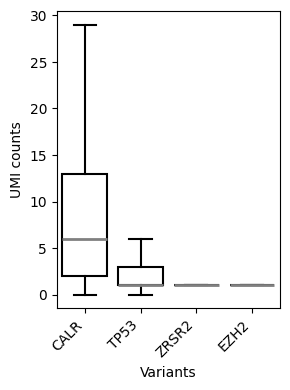

In [5]:
fig,ax = plt.subplots(figsize=(3,4))

data_to_plot = []
labels = []

for variant in ['CALR c.1150_1154delinsTGTC', 'TP53 c.818G>A', 'ZRSR2 c.883C>T', 'EZH2 c.2054G>A']:

    data = adata.obsm['genotypes'][f'{variant}_high_confidence_counts']
    data_to_plot.append(data)
    labels.append(variant.split(' ')[0])

# Remove NaN values from each dataset
data_to_plot_clean = [data.dropna() for data in data_to_plot]

bp = ax.boxplot(data_to_plot_clean, labels=labels, patch_artist=True, showfliers=False, widths=0.8)

# Style the boxplots - remove fill and make median lines black
for patch in bp['boxes']:
    patch.set_facecolor('none')
    patch.set_linewidth(1.5)

for median_line in bp['medians']:
    median_line.set_color('grey')
    median_line.set_linewidth(2)

for whisker in bp['whiskers']:
    whisker.set_linewidth(1.5)

for cap in bp['caps']:
    cap.set_linewidth(1.5)

ax.set_ylabel('UMI counts')
ax.set_xlabel('Variants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../plots/variant_umi_counts_boxplot.pdf', dpi=300, bbox_inches='tight')

In [6]:
for i in range(0,len(data_to_plot_clean)):
    print(f"{labels[i]}: n = {len(data_to_plot_clean[i])}")

CALR: n = 27180
TP53: n = 16845
ZRSR2: n = 5230
EZH2: n = 6894


In [7]:
### check CALR median UMI counts
data_to_plot_clean[0].median()

6.0

/tmp/ipykernel_369097/1694029859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)


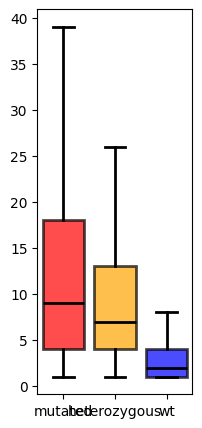

In [8]:
for variant in ['CALR c.1150_1154delinsTGTC']:
    fig,ax = plt.subplots(figsize=(2,5))

    data_to_plot = []
    labels = []

    for genotype in ['mutated','heterozygous','wt']:
        genotype_data = adata[adata.obsm['genotype_call'][variant] == genotype].obsm['genotypes'][f'{variant}_high_confidence_counts']
        data_to_plot.append(genotype_data)
        labels.append(genotype)

    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)

    # Color the boxplots
    for patch, genotype in zip(bp['boxes'], labels):
        patch.set_facecolor(color_palette[genotype])
        patch.set_linewidth(2)
        patch.set_alpha(0.7)
    # Style the other boxplot elements
    for whisker in bp['whiskers']:
        whisker.set_linewidth(2)
    for cap in bp['caps']:
        cap.set_linewidth(2)
    for median_line in bp['medians']:
        median_line.set_color('black')
        median_line.set_linewidth(2)
plt.savefig('../plots/CALR_umi_counts_by_genotype_boxplot.pdf', dpi=300, bbox_inches='tight')

In [9]:
st.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='greater')

MannwhitneyuResult(statistic=49500309.0, pvalue=4.541154793107311e-48)

In [10]:
st.mannwhitneyu(data_to_plot[1], data_to_plot[2], alternative='greater')

MannwhitneyuResult(statistic=16100483.5, pvalue=0.0)

In [11]:
## cell counts per box
len(data_to_plot[0]), len(data_to_plot[1]), len(data_to_plot[2])

(14726, 5957, 3348)

In [12]:
def get_genotype_stats(adata, clone, variant, isolate_cluster=False, cluster = ''):
    adata.obs['max_prob'] = adata.obsm['genotypes'][[f'{variant}_wt', f'{variant}_mutated', f'{variant}_heterozygous']].max(axis=1)

    genotype_frac = {'wt' : {},
                    'mutated' : {},
                    'heterozygous' : {}}
    UMI_counts = {}

    for threshold in np.arange(0.6, 1.01, 0.01):
        condition = (adata.obs['clone'] == clone) & (adata.obs['max_prob'] > threshold)
        if isolate_cluster:
            condition = condition & (adata.obs['pheno_leiden'] == cluster)
        if len(adata[condition].obs) > 200:
            val_counts = adata[condition].obsm['genotype_call'][variant].value_counts(normalize=True)
            for genotype in ['wt','mutated','heterozygous']:
                if genotype in val_counts.index:
                    genotype_frac[genotype][threshold] = val_counts.loc[genotype]
                else:
                    genotype_frac[genotype][threshold] = 0
            UMI_counts[threshold] = adata[condition].obsm['genotypes'][f'{variant}_high_confidence_counts'].median()
    return genotype_frac, UMI_counts

def plot_genotype_fractions(variant, ylim, xlim, save=False):

    for clone in adata.obs['clone'].dropna().unique():

        genotype_frac, UMI_counts = get_genotype_stats(adata, clone, variant)

        if len(UMI_counts) > 0:

            plt.figure(figsize=(4,4))

            for genotype, color in zip(['wt','mutated','heterozygous'], ['blue', 'red', 'orange']):
                plt.plot(list(genotype_frac[genotype].keys()), list(genotype_frac[genotype].values()), marker='o', color = color, label=genotype)

            plt.ylabel('Genotype fraction')
            plt.ylim(0,1)
            plt.xlim(xlim)
            plt.legend()

            # Create second y-axis for UMI counts
            ax2 = plt.gca().twinx()
            ax2.plot(list(UMI_counts.keys()), list(UMI_counts.values()), 'k--', alpha=0.7, label='UMI counts')
            ax2.set_ylabel('UMI counts')
            ax2.set_ylim(ylim)

            plt.xlabel('High confidence count threshold')

            plt.title(f'Clone: {clone}, Variant: {variant}')

            if save:
                plt.savefig(f'../plots/{variant.split(" ")[0]}_genotype_fractions_clone_{clone}.pdf', dpi=300, bbox_inches='tight')
            else:
                plt.show()


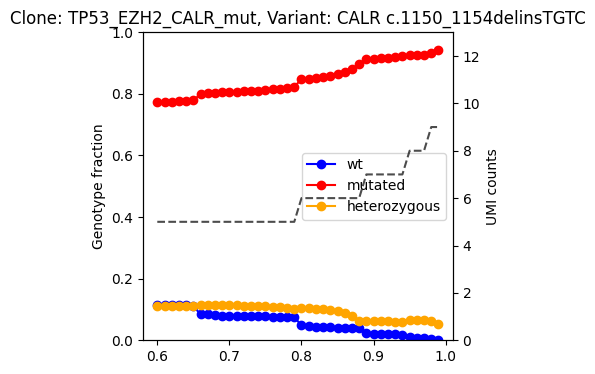

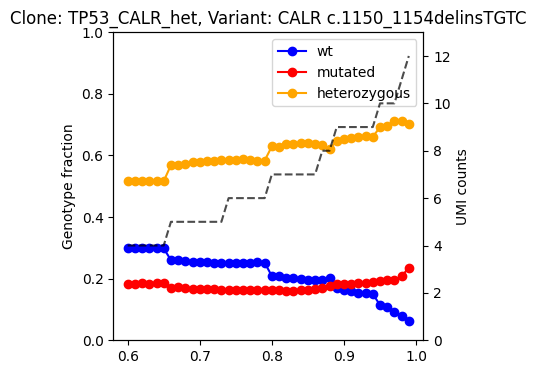

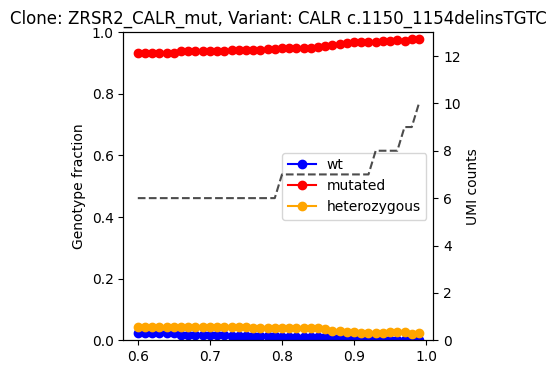

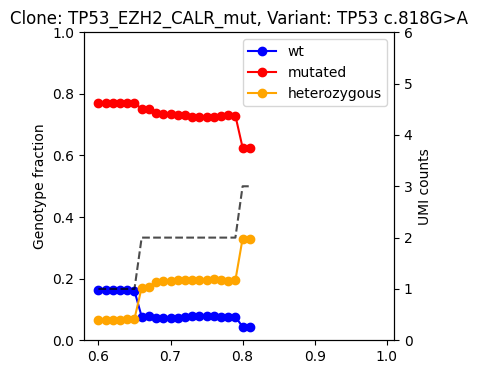

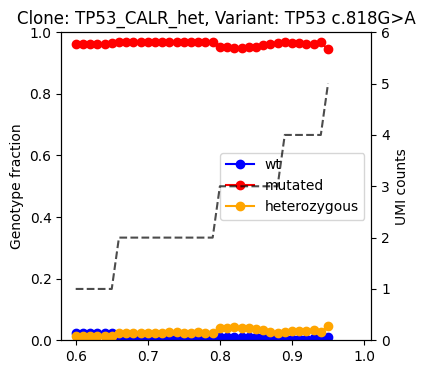

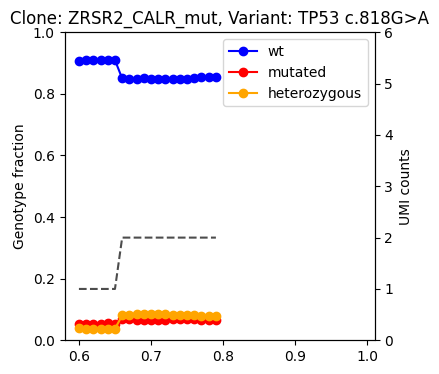

In [13]:
variant = 'CALR c.1150_1154delinsTGTC'
plot_genotype_fractions(variant, (0,13), (0.58,1.01), save=True)

variant = 'TP53 c.818G>A'
plot_genotype_fractions(variant, (0,6), (0.58, 1.01), save=True)


In [14]:
gf_dir = large_data_dir + 'gf_MPN/gf_MPN_16plex_part1_1/BC7_giftwrap/'
probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold = 15, min_percent_supporting = -1, cell_barcode_suffix = '-0', adata_path = adata_dir, collapse_across_probes=True)

gf_dir = large_data_dir + 'gf_MPN/gf_MPN_16plex_part1_2/BC7_giftwrap/'
probe_reads = pd.concat([probe_reads, gf_utils.get_input_probe_reads(gf_dir, read_threshold = 15, min_percent_supporting = -1, cell_barcode_suffix = '-1', adata_path = adata_dir, collapse_across_probes=True)])

manifest = gf_utils.get_manifest(gf_dir)


1756198 UMIs found
Collapsing UMIs across probes, 1756198 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (15) and min percent supporting (-1), 1345516 UMIs remaining (76.62%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 1265530 UMIs remaining (72.06%)
2010873 UMIs found
Collapsing UMIs across probes, 2010873 UMIs remaining (100.00%)
Filtering probe reads based on read threshold (15) and min percent supporting (-1), 1517763 UMIs remaining (75.48%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 1422389 UMIs remaining (70.73%)


Variant: CALR c.1150_1154delinsTGTC
mut=28519, wt=33965, total=62484, observed p=0.4564
Exact binomial test p-value (p != 0.5): 1.000e+00
Variant: TP53 c.818G>A
mut=3362, wt=1975, total=5337, observed p=0.6299
Exact binomial test p-value (p != 0.5): 1.814e-81


/tmp/ipykernel_369097/4260849440.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)


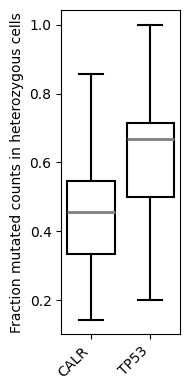

In [15]:
prop = {}

for variant in ['CALR c.1150_1154delinsTGTC','TP53 c.818G>A']:
    probe_idx = manifest.loc[manifest['name'] == variant].index.values[0]
    wt_gapfill = manifest.loc[probe_idx,'gapfill_from_transcriptome']
    mutated_gapfill = manifest.loc[probe_idx,'gap_probe_sequence']

    adata.obs['wt_counts'] = probe_reads.loc[(probe_reads['probe_idx'] == probe_idx) & (probe_reads['gapfill'] == wt_gapfill)].groupby('barcode').size()
    adata.obs['wt_counts'] = adata.obs['wt_counts'].fillna(0)
    adata.obs['mutated_counts'] = probe_reads.loc[(probe_reads['probe_idx'] == probe_idx) & (probe_reads['gapfill'] == mutated_gapfill)].groupby('barcode').size()
    adata.obs['mutated_counts'] = adata.obs['mutated_counts'].fillna(0)

    adata.obs['fraction_mutated_counts'] = adata.obs['mutated_counts'] / (adata.obs[['mutated_counts','wt_counts']].sum(axis=1))

    het_mask = adata.obsm['genotype_call'][variant] == 'heterozygous'
    prop[variant] = adata[het_mask].obs['fraction_mutated_counts']

    ### run binomial test for deviation from 0.5 in heterozygous cells
    mut = adata.obs.loc[het_mask, 'mutated_counts'].sum()
    wt = adata.obs.loc[het_mask, 'wt_counts'].sum()
    n = mut + wt

    # frequentist: two-sided p-value for H0: p = 0.5
    res = st.binomtest(k=int(mut), n=int(n), p=0.5, alternative='greater')

    print(f"Variant: {variant}")
    print(f"mut={mut:.0f}, wt={wt:.0f}, total={n:.0f}, observed p={mut/n:.4f}")
    print(f"Exact binomial test p-value (p != 0.5): {res.pvalue:.3e}")


fig, ax = plt.subplots(figsize=(2, 4))

data_to_plot = [prop[v].dropna() for v in prop]
labels = [v.split(' ')[0] for v in prop]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)

for patch in bp['boxes']:
    patch.set_facecolor('none')
    patch.set_linewidth(1.5)
for median in bp['medians']:
    median.set_color('grey')
    median.set_linewidth(2)
for whisker in bp['whiskers']:
    whisker.set_linewidth(1.5)
for cap in bp['caps']:
    cap.set_linewidth(1.5)

ax.set_ylabel('Fraction mutated counts in heterozygous cells')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'../plots/fraction_mutated_in_heterozyotes_boxplots.pdf', dpi=300, bbox_inches='tight')